# Bi-Kappa Distribution Sampling

This notebook implements sampling from the bi-kappa distribution using a radially symmetric approach.

## Distribution Definition
The bi-kappa density is:
$$
f(v_x,v_y,v_z)=\frac{\Gamma(\kappa+1)}{\pi^{3/2}\,\theta_\perp^2\,\theta_\parallel\,\kappa^{3/2}\,\Gamma\!\left(\kappa-\tfrac12\right)}
\Bigl(1+\frac{v_x^2+v_y^2}{\kappa\,\theta_\perp^2}+\frac{v_z^2}{\kappa\,\theta_\parallel^2}\Bigr)^{-(\kappa+1)}
$$

## Sampling Algorithm
1. **Isotropize** by scaling to u-space
2. **Sample radius** using Beta-prime distribution (Gamma ratio)
3. **Sample direction** uniformly on sphere
4. **Transform back** to v-space

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from scipy.special import gamma

In [11]:
def sample_bi_kappa(kappa, theta_perp, theta_para, n_samples=1):
    if kappa <= 0.5:
        raise ValueError("kappa must be > 0.5 for normalization")
    if theta_perp <= 0 or theta_para <= 0:
        raise ValueError("Temperature parameters must be positive")
    
    # Vectorized sampling
    # Step 1: Sample radii using Beta-prime = Gamma ratio
    X1 = np.random.gamma(shape=1.5, scale=1.0, size=n_samples)
    X2 = np.random.gamma(shape=kappa - 0.5, scale=1.0, size=n_samples)
    T = X1 / X2
    R = np.sqrt(T)
    
    # Step 2: Sample directions uniformly on S^2
    cos_theta = np.random.uniform(-1.0, 1.0, size=n_samples)
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = np.random.uniform(0, 2 * np.pi, size=n_samples)
    
    # u vectors
    Ux = R * sin_theta * np.cos(phi)
    Uy = R * sin_theta * np.sin(phi)
    Uz = R * cos_theta
    
    # Step 3: Map back to v-space
    Vx = np.sqrt(kappa) * theta_perp * Ux
    Vy = np.sqrt(kappa) * theta_perp * Uy
    Vz = np.sqrt(kappa) * theta_para * Uz
    
    samples = np.column_stack((Vx, Vy, Vz))
    
    return samples

def sample_bi_maxwellian(theta_perp, theta_para, n_samples=1):
    if theta_perp <= 0 or theta_para <= 0:
        raise ValueError("Temperature parameters must be positive")
    
    # Sample from normal distributions
    # v_perp^2 = vx^2 + vy^2, each component has std = theta_perp/sqrt(2)
    Vx = np.random.normal(0, theta_perp / np.sqrt(2), size=n_samples)
    Vy = np.random.normal(0, theta_perp / np.sqrt(2), size=n_samples)
    Vz = np.random.normal(0, theta_para / np.sqrt(2), size=n_samples)
    
    samples = np.column_stack((Vx, Vy, Vz))
    
    return samples

## Example: Generate Samples

Let's generate samples and visualize the distribution.

In [12]:
def generate_samples(kappa, theta_perp, theta_para, n_samples):
    """
    Generate samples from the bi-kappa distribution.
    
    Parameters
    ----------
    kappa : float
        Shape parameter (must be > 0.5)
    theta_perp : float
        Perpendicular temperature parameter
    theta_para : float
        Parallel temperature parameter
    n_samples : int
        Number of samples to generate
        
    Returns
    -------
    samples : ndarray
        Array of shape (n_samples, 3) containing [vx, vy, vz] samples
    """
    samples = sample_bi_kappa(kappa, theta_perp, theta_para, n_samples)
    
    print(f"Generated {n_samples} samples from bi-kappa distribution")
    print(f"Parameters: κ={kappa}, Θ_⊥={theta_perp}, Θ_∥={theta_para}")
    print(f"\nSample statistics:")
    print(f"Mean: vx={samples[:,0].mean():.4f}, vy={samples[:,1].mean():.4f}, vz={samples[:,2].mean():.4f}")
    print(f"Std:  vx={samples[:,0].std():.4f}, vy={samples[:,1].std():.4f}, vz={samples[:,2].std():.4f}")
    
    return samples


# Set parameters
kappa = 2         # Shape parameter (must be > 0.5)
theta_perp = 1.0     # Perpendicular temperature
theta_para = 1.0     # Parallel temperature (anisotropic case)
n_samples = 100000    # Number of samples

# Generate samples
# samples = generate_samples(kappa, theta_perp, theta_para, n_samples)
samples = np.loadtxt("../cpp/samples_bikappa.txt")


## Visualization

In [13]:
def visualize_samples(samples, kappa, theta_perp, theta_para):
    """
    Visualize marginal distributions of samples with comparison to normal distributions.
    
    Parameters
    ----------
    samples : ndarray
        Array of shape (n_samples, 3) containing [vx, vy, vz] samples
    kappa : float
        Shape parameter used to generate samples
    theta_perp : float
        Perpendicular temperature parameter
    theta_para : float
        Parallel temperature parameter
    """
    from scipy.stats import gaussian_kde
    
    # Marginal distributions (trim extremes first)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

    # Determine percentile-based cut bounds using all data
    all_data = samples.flatten()
    lower = np.percentile(all_data, 0.5)
    upper = np.percentile(all_data, 99.5)

    # Create sample_cut: keep rows where all components lie within [lower, upper]
    mask = np.all((samples >= lower) & (samples <= upper), axis=1)
    sample_cut = samples[mask]
    # Fallback: if trimming removes everything (unlikely), use full samples
    if sample_cut.shape[0] == 0:
        sample_cut = samples

    # Create x-values for plotting curves based on trimmed samples
    x_min, x_max = sample_cut.min(), sample_cut.max()
    x_range = np.linspace(x_min, x_max, 1000)

    # vx distribution (use trimmed samples)
    axes[0].hist(sample_cut[:, 0], bins=50, density=True, alpha=0.5, edgecolor='black', label='Histogram')
    kde_vx = gaussian_kde(samples[:, 0])
    line_kde_vx, = axes[0].plot(x_range, kde_vx(x_range), 'b-', linewidth=2)
    # Overlay normal distribution with same mean and std
    vx_mean, vx_std = 0, theta_perp/np.sqrt(2)
    line_norm_vx, = axes[0].plot(x_range, stats.norm.pdf(x_range, vx_mean, vx_std), 'r--', linewidth=2)
    axes[0].set_xlabel('$v_x$')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Marginal distribution of $V_x$')
    axes[0].grid(True, alpha=0.3)

    # vy distribution
    axes[1].hist(sample_cut[:, 1], bins=50, density=True, alpha=0.5, edgecolor='black', label='Histogram')
    kde_vy = gaussian_kde(samples[:, 1])
    line_kde_vy, = axes[1].plot(x_range, kde_vy(x_range), 'b-', linewidth=2)
    vy_mean, vy_std = 0, theta_perp/np.sqrt(2)
    line_norm_vy, = axes[1].plot(x_range, stats.norm.pdf(x_range, vy_mean, vy_std), 'r--', linewidth=2)
    axes[1].set_xlabel('$v_y$')
    axes[1].set_title('Marginal distribution of $V_y$')
    axes[1].grid(True, alpha=0.3)

    # vz distribution
    axes[2].hist(sample_cut[:, 2], bins=50, density=True, alpha=0.5, edgecolor='black', label='Histogram')
    kde_vz = gaussian_kde(samples[:, 2])
    line_kde_vz, = axes[2].plot(x_range, kde_vz(x_range), 'b-', linewidth=2)
    vz_mean, vz_std = 0, theta_para/np.sqrt(2)
    line_norm_vz, = axes[2].plot(x_range, stats.norm.pdf(x_range, vz_mean, vz_std), 'r--', linewidth=2)
    axes[2].set_xlabel('$v_z$')
    axes[2].set_title('Marginal distribution of $V_z$')
    axes[2].grid(True, alpha=0.3)

    # Create a single shared legend for the whole figure. Use representative proxy handles.
    rep_handles = [plt.Line2D([0], [0], color='black', lw=6, alpha=0.5),  # histogram proxy
                   plt.Line2D([0], [0], color='b', lw=2),                # KDE proxy
                   plt.Line2D([0], [0], color='r', lw=2, linestyle='--')] # Normal proxy
    rep_labels = ['Histogram for samples', 'Fitted curve (KDE from samples)', 'Maxwellian']

    # Place the legend above the plots, centered. Use ncol=3 so labels appear side-by-side.
    fig.legend(rep_handles, rep_labels, loc='upper center', bbox_to_anchor=(0.5, 0.925), ncol=3, frameon=False, fontsize=10)

    # Set xlim to the percentile bounds for all subplots
    for ax in axes:
        ax.set_xlim(lower, upper)

    # Leave room at the top for the shared legend
    plt.suptitle(r"Marginal distributions of $(V_x,V_y,V_z)$ with $\kappa="+f"{kappa}$")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'marginal-normal-comparison-k={kappa}.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nTrimmed samples: kept {sample_cut.shape[0]} / {samples.shape[0]} rows (within {lower:.3f}..{upper:.3f})")
    print(f"Note: vx and vy should have similar spreads (Θ_⊥={theta_perp})")
    print(f"      vz should have different spread (Θ_∥={theta_para})")
    print(f"\nVisualization shows:")
    print(f"  - Histogram: Trimmed sampled data distribution")
    print(f"  - Blue solid line: Fitted curve using Kernel Density Estimation (KDE)")
    print(f"  - Red dashed line: Normal distribution for comparison")
    print(f"\nBi-kappa has heavier tails than Gaussian - notice the difference at extreme values!")


# Visualize the samples
# visualize_samples(samples, kappa, theta_perp, theta_para)

## Verification: Compare with Theoretical Moments

For $\kappa > \frac{3}{2}$, the theoretical variance exists and can be computed.

In [14]:
def verify_samples(samples, kappa, theta_perp, theta_para):
    """
    Verify samples by comparing empirical moments with theoretical predictions.
    
    Parameters
    ----------
    samples : ndarray
        Array of shape (n_samples, 3) containing [vx, vy, vz] samples
    kappa : float
        Shape parameter used to generate samples
    theta_perp : float
        Perpendicular temperature parameter
    theta_para : float
        Parallel temperature parameter
    """
    # For kappa distribution, the theoretical variance is:
    if kappa > 1.5:
        theoretical_var_vx = kappa*theta_perp**2/(2*kappa-3)
        theoretical_var_vz = kappa*theta_para**2/(2*kappa-3)
        theoretical_var_perp = kappa*theta_perp**2/(kappa-1.5) -\
                                np.pi*theta_perp**2*kappa*gamma(kappa-1)**2/(4*gamma(kappa-0.5)**2)
        
        vperp = np.sqrt(samples[:,0]**2 + samples[:,1]**2)
        empirical_var_vx = np.var(samples[:, 0], ddof=1)
        empirical_var_vy = np.var(samples[:, 1], ddof=1)
        empirical_var_vz = np.var(samples[:, 2], ddof=1)
        empirical_var_vperp = np.var(vperp, ddof=1)

        
        print("Theoretical vs Sample Variance:")
        print("=" * 50)
        print(f"v_x: {theoretical_var_vx:.4f} (theory) vs {empirical_var_vx:.4f} (sample)")
        print(f"v_y: {theoretical_var_vx:.4f} (theory) vs {empirical_var_vy:.4f} (sample)")
        print(f"v_perp: {theoretical_var_perp:.4f} (theory) vs {empirical_var_vperp:.4f} (sample)")
        print(f"v_z: {theoretical_var_vz:.4f} (theory) vs {empirical_var_vz:.4f} (sample)")
        print("\nRelative errors:")
        print(f"v_x: {abs(empirical_var_vx - theoretical_var_vx)/theoretical_var_vx * 100:.2f}%")
        print(f"v_y: {abs(empirical_var_vy - theoretical_var_vx)/theoretical_var_vx * 100:.2f}%")
        print(f"v_perp: {abs(empirical_var_vperp - theoretical_var_perp)/theoretical_var_perp * 100:.2f}%")
        print(f"v_z: {abs(empirical_var_vz - theoretical_var_vz)/theoretical_var_vz * 100:.2f}%")
    else:
        print(f"κ = {kappa} ≤ 3/2, variance does not exist theoretically")


# Verify the samples
# verify_samples(samples, kappa, theta_perp, theta_para)

## QQ-Plots to Verify Bi-Kappa Distribution

QQ-plots compare the empirical quantiles with theoretical quantiles to assess goodness-of-fit.

In [15]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.special import gamma
from math import sqrt, pi

# Define PDF

def kappa_pdf(v, kappa, theta, direction):
    # Analytical marginal PDFs for specific kappas (theta included via scaling if needed)
    v = float(v)
    if kappa == 2:
        if direction == "perp":
            return (4.0 * np.sqrt(2.0)) / (np.pi * (2.0 + v**2)**2)
        elif direction == "para":
            return (32.0 * np.sqrt(2.0)) / (np.pi * (8.0 + v**2)**2)
        else:
            raise ValueError("direction must be 'para' or 'perp'")
    elif kappa == 5:
        if direction == "perp":
            return (16000.0 * np.sqrt(5.0)) / (7.0 * np.pi * (5.0 + v**2)**5)
        elif direction == "para":
            return (8192000.0 * np.sqrt(5.0)) / (7.0 * np.pi * (20.0 + v**2)**5)
        else:
            raise ValueError("direction must be 'para' or 'perp'")
    else:
        # For unsupported kappas, raise to signal numeric fallback should be used elsewhere.
        raise NotImplementedError(f"No analytic PDF defined for kappa={kappa}")


def get_integration_limit(kappa, theta, direction, tol=1e-8, max_L=1e4, initial_L=None):
    """
    Adaptively choose an integration limit L so that the integral of the marginal PDF
    over [-L, L] captures at least (1 - tol) of the total probability mass.

    This works only when `kappa_pdf` is implemented for the requested kappa/direction.
    If `kappa_pdf` raises NotImplementedError, the function falls back to a heuristic L.
    """
    if initial_L is None:
        L = max(10.0 * theta * np.sqrt(max(1.0, kappa)), 1.0)
    else:
        L = initial_L

    try:
        # Increase L until the normalized mass within [-L,L] is >= 1 - tol, or L exceeds max_L.
        while L <= max_L:
            mass, _ = quad(lambda x: kappa_pdf(x, kappa, theta, direction), -L, L)
            if mass >= 1.0 - tol:
                return L
            L *= 2.0
        # If we reach here, return the last L (may be insufficient but prevents infinite loop)
        return min(L, max_L)
    except NotImplementedError:
        # Can't compute adaptively; return heuristic
        return max(10.0 * theta * np.sqrt(max(1.0, kappa)), 1.0)


def kappa_cdf(v, kappa, theta, direction):
    """
    Return the marginal CDF for given scalar v, kappa and direction ('perp' or 'para').
    For kappa=2 and kappa=5 we use closed-form expressions derived analytically.
    For other kappa values we fall back to numeric integration of kappa_pdf over an adaptive range.
    """
    v = float(v)

    if kappa == 2:
        if direction == 'perp':
            return 0.5 + (np.sqrt(2.0) * v) / (np.pi * (2.0 + v**2)) + np.arctan(v / np.sqrt(2.0)) / np.pi
        elif direction == 'para':
            return 0.5 + (2.0 * np.sqrt(2.0) * v) / (np.pi * (8.0 + v**2)) + np.arctan(v / (2.0 * np.sqrt(2.0))) / np.pi
        else:
            raise ValueError("direction must be 'para' or 'perp'")

    elif kappa == 5:
        if direction == 'perp':
            num_poly = 6975.0 + 7.0 * v**2 * (365.0 + 55.0 * v**2 + 3.0 * v**4)
            term = (np.sqrt(5.0) * v * num_poly) / (21.0 * np.pi * (5.0 + v**2)**4)
            return 0.5 + term + np.arctan(v / np.sqrt(5.0)) / np.pi
        elif direction == 'para':
            num_poly = 446400.0 + 7.0 * v**2 * (5840.0 + 220.0 * v**2 + 3.0 * v**4)
            term = (2.0 * np.sqrt(5.0) * v * num_poly) / (21.0 * np.pi * (20.0 + v**2)**4)
            return 0.5 + term + np.arctan(v / (2.0 * np.sqrt(5.0))) / np.pi
        else:
            raise ValueError("direction must be 'para' or 'perp'")

    else:
        # Numeric fallback: adaptively choose L and integrate
        try:
            L = get_integration_limit(kappa, theta, direction)
            integral, _ = quad(lambda x: kappa_pdf(x, kappa, theta, direction), -L, v)
            norm, _ = quad(lambda x: kappa_pdf(x, kappa, theta, direction), -L, L)
            return integral / norm
        except NotImplementedError:
            # As a last resort, fall back to heuristic L
            L = max(10.0 * theta * np.sqrt(max(1.0, kappa)), 1.0)
            integral, _ = quad(lambda x: kappa_pdf(x, kappa, theta, direction), -L, v)
            norm, _ = quad(lambda x: kappa_pdf(x, kappa, theta, direction), -L, L)
            return integral / norm


def kappa_ppf(p, kappa, theta, direction):
    # Handle edge cases
    if p <= 0.0:
        return -np.inf
    if p >= 1.0:
        return np.inf

    # Choose integration limit for bracketing; use adaptive choice when possible
    L = max(10.0 * theta * np.sqrt(max(1.0, kappa)), 1.0)

    # Find bracket where cdf(a) < p < cdf(b)
    a, b = -L, L
    fa = kappa_cdf(a, kappa, theta, direction) - p
    fb = kappa_cdf(b, kappa, theta, direction) - p
    if fa * fb > 0:
        # Try expanding bracket a few times
        factor = 2.0
        for _ in range(5):
            a *= factor
            b *= factor
            fa = kappa_cdf(a, kappa, theta, direction) - p
            fb = kappa_cdf(b, kappa, theta, direction) - p
            if fa * fb <= 0:
                break
        else:
            raise ValueError("Could not bracket root for ppf: p out of CDF range after expanding bracket.")

    sol = root_scalar(lambda v: kappa_cdf(v, kappa, theta, direction) - p, bracket=[a, b], method='brentq')
    if not sol.converged:
        print(f"Warning: root finding did not converge for p={p}")
        return np.nan
    return sol.root


def theoretical_quantile_bi_kappa_marginal(p_array, kappa, theta, direction):
    vectorized_ppf = np.vectorize(kappa_ppf)
    return vectorized_ppf(p_array, kappa, theta, direction)


In [16]:
def qqplot_samples(samples, kappa, theta_perp, theta_para, dpi=200, save=True, add_bimaxwellian=False):
    """Create QQ-plots comparing sample marginals to theoretical bi-kappa marginals.

    Parameters
    ----------
    samples : ndarray
        (n_samples, 3) array of vx, vy, vz
    kappa : float
        Shape parameter
    theta_perp : float
        Perpendicular temperature
    theta_para : float
        Parallel temperature
    dpi : int
        Figure DPI
    save : bool
        Whether to save the figure to disk
    add_bimaxwellian: bool
        Whether to overlay bi-Maxwellian QQ-plots for comparison
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), dpi=dpi)

    components = ['$V_x$', '$V_y$', '$V_z$']
    theta_values = [theta_perp, theta_perp, theta_para]
    directions = ['perp', 'perp', 'para']

    r2_values = []

    BM_samples = sample_bi_maxwellian(theta_perp, theta_para, samples.shape[0])

    for idx, (ax, comp, theta, direction) in enumerate(zip(axes, components, theta_values, directions)):
        # Get empirical data
        data = samples[:, idx]

        # Sort the data
        sorted_data = np.sort(data)

        # Calculate empirical quantiles (probabilities)
        n = len(sorted_data)
        empirical_probs = (np.arange(1, n + 1) - 0.5) / n

        # Calculate theoretical quantiles using the existing PPF wrapper
        theoretical_quantiles = theoretical_quantile_bi_kappa_marginal(empirical_probs, kappa, theta, direction)

        # Create QQ-plot
        ax.scatter(theoretical_quantiles, sorted_data, alpha=0.5, s=1, label='Bi-kappa quantiles')

        # Create QQ-plot for bi-maxwellian
        if(add_bimaxwellian):
            BM_data = BM_samples[:, idx]
            BM_sorted_data = np.sort(BM_data)
            ax.scatter(theoretical_quantiles, BM_sorted_data, alpha=0.5, s=1, color='orange', label='Bi-Maxwellian quantiles')

        # Add reference line (perfect fit)
        # handle possible NaNs in theoretical_quantiles
        mask = ~np.isnan(theoretical_quantiles)
        if mask.sum() == 0:
            min_val, max_val = sorted_data.min(), sorted_data.max()
        else:
            min_val = min(theoretical_quantiles[mask].min(), sorted_data.min())
            max_val = max(theoretical_quantiles[mask].max(), sorted_data.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')

        # Calculate R² to quantify goodness of fit (handle constant arrays)
        try:
            correlation = np.corrcoef(theoretical_quantiles[mask], sorted_data[mask])[0, 1]
            r_squared = float(correlation ** 2)
        except Exception:
            r_squared = np.nan

        r2_values.append(r_squared)

        # Labels and title
        ax.set_xlabel('Theoretical Bi-Kappa Quantiles', fontsize=11)
        ax.set_ylabel('Sample Quantiles', fontsize=11)
        ax.set_title(f'QQ-Plot for {comp}\n(κ={kappa}, θ={theta}, R²={r_squared:.4f})', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout(h_pad=12)
    if save:
        plt.savefig(f'marginal-qqplot-k={kappa}.png', bbox_inches='tight')
    plt.show()

    print("QQ-Plot Interpretation:")
    print("- Points close to the red line indicate good fit to the bi-kappa distribution")
    print("- R² values close to 1.0 indicate excellent agreement with theoretical distribution")
    print("\nR² values:")
    for comp, r2 in zip(components, r2_values):
        print(f"  {comp}: R² = {np.nan_to_num(r2, nan=float('nan')):.6f}")


# Call the new function
# qqplot_samples(samples, kappa, theta_perp, theta_para)

In [17]:
# samples_k2 = generate_samples(2, theta_perp, theta_para, n_samples)
# samples_k5 = generate_samples(5, theta_perp, theta_para, n_samples)
# samples_k10 = generate_samples(10, theta_perp, theta_para, n_samples)

# visualize_samples(samples_k2, 2, theta_perp, theta_para)
# visualize_samples(samples_k5, 5, theta_perp, theta_para)
# visualize_samples(samples_k10, 10, theta_perp, theta_para)

# verify_samples(samples_k2, 2, theta_perp, theta_para)
# verify_samples(samples_k5, 5, theta_perp, theta_para)
# verify_samples(samples_k10, 10, theta_perp, theta_para)

# qqplot_samples(samples_k2, 2, theta_perp, theta_para, add_bimaxwellian=True)
# qqplot_samples(samples_k5, 5, theta_perp, theta_para, add_bimaxwellian=True)

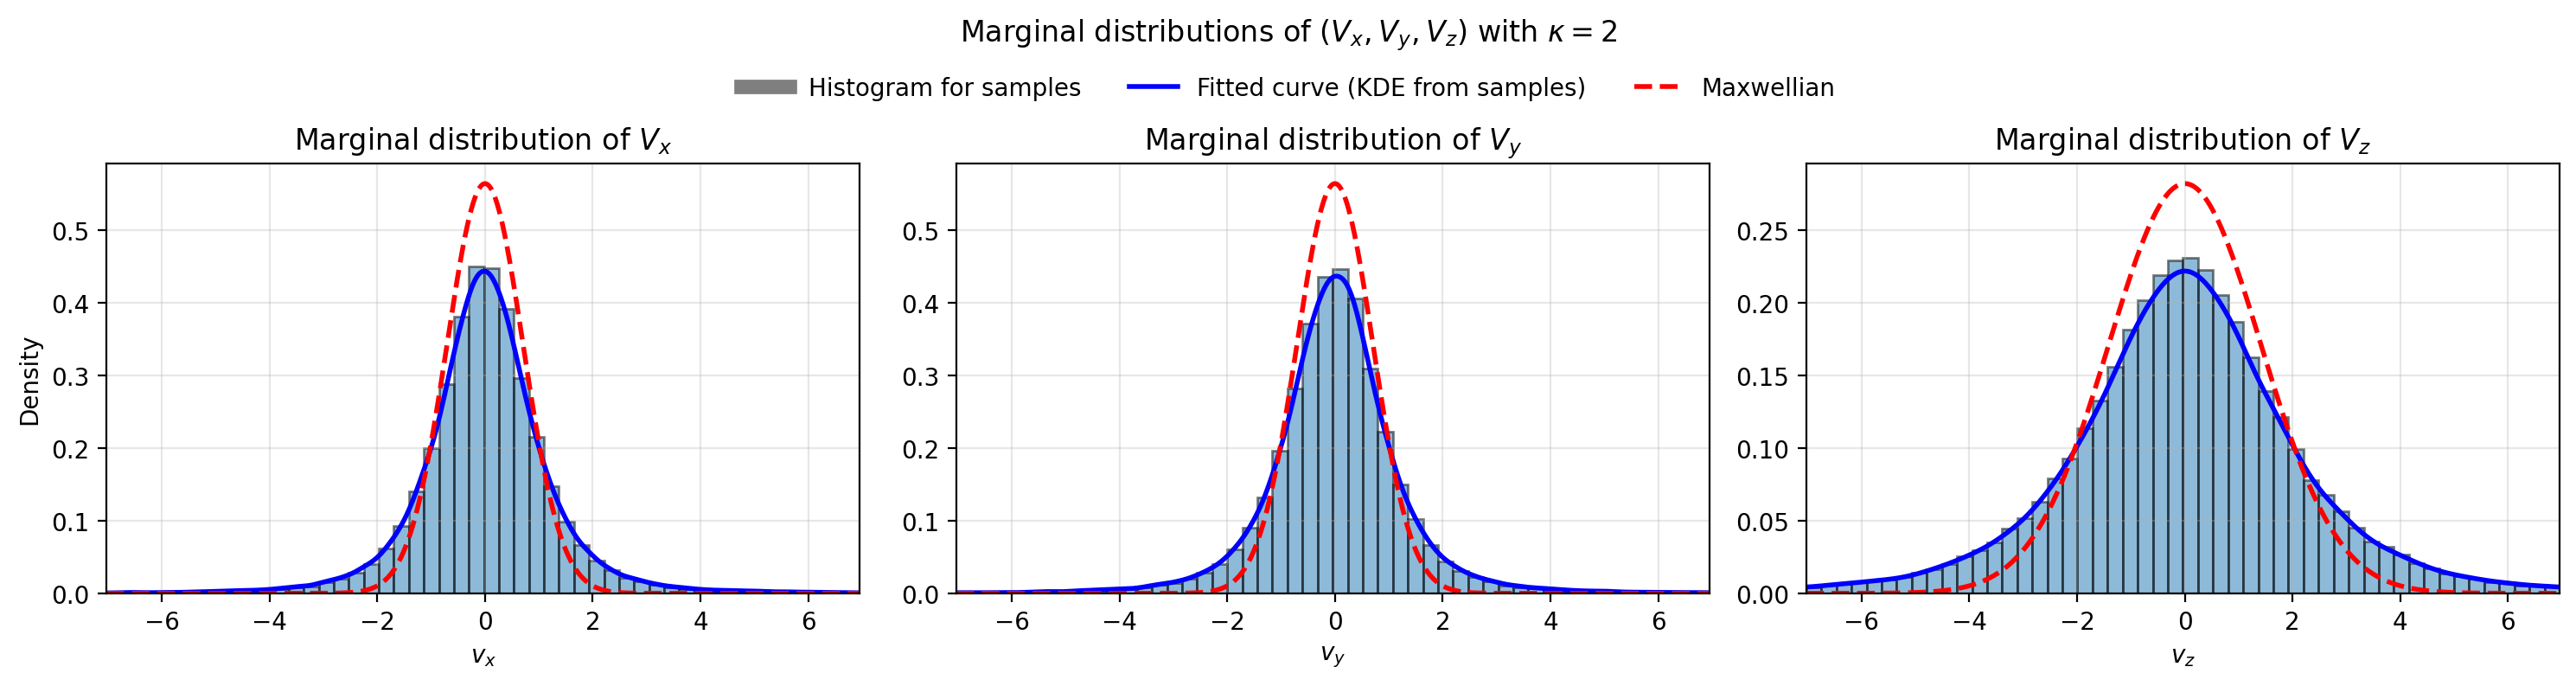


Trimmed samples: kept 97372 / 100000 rows (within -7.031..6.956)
Note: vx and vy should have similar spreads (Θ_⊥=1.0)
      vz should have different spread (Θ_∥=2.0)

Visualization shows:
  - Histogram: Trimmed sampled data distribution
  - Blue solid line: Fitted curve using Kernel Density Estimation (KDE)
  - Red dashed line: Normal distribution for comparison

Bi-kappa has heavier tails than Gaussian - notice the difference at extreme values!
Theoretical vs Sample Variance:
v_x: 2.0000 (theory) vs 2.0108 (sample)
v_y: 2.0000 (theory) vs 2.0351 (sample)
v_perp: 2.0000 (theory) vs 2.0285 (sample)
v_z: 8.0000 (theory) vs 7.5642 (sample)

Relative errors:
v_x: 0.54%
v_y: 1.76%
v_perp: 1.42%
v_z: 5.45%


In [18]:
# Set parameters
kappa = 2         # Shape parameter (must be > 0.5)
theta_perp = 1.0     # Perpendicular temperature
theta_para = 2.0     # Parallel temperature (anisotropic case)
samples_cpp = np.loadtxt('../cpp/samples_bikappa.txt')
visualize_samples(samples_cpp, kappa, theta_perp, theta_para)
verify_samples(samples_cpp, kappa, theta_perp, theta_para)
# qqplot_samples(samples_cpp, kappa, theta_perp, theta_para, add_bimaxwellian=True)